In [9]:
import os
from pathlib import Path

ROOT_DIR_BRAINTREEBANK = Path(r"C:\Users\simon\PyCharmMiscProject\neuroprobe-dev\braintreebank")
os.environ["ROOT_DIR_BRAINTREEBANK"] = str(ROOT_DIR_BRAINTREEBANK)

assert ROOT_DIR_BRAINTREEBANK.exists(), ROOT_DIR_BRAINTREEBANK

In [10]:
CHECKPOINT_DIR = Path("notebooks/models")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

RUN_TAG = "acoustic_core_v1"
CHECKPOINT_PATH = CHECKPOINT_DIR / f"leaderboard_{RUN_TAG}_best.pt"
print("Checkpoint will be saved to:", CHECKPOINT_PATH)

Checkpoint will be saved to: notebooks\models\leaderboard_acoustic_core_v1_best.pt


In [11]:
# Standard library
import copy
import inspect
import json
import random

# Third-party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


# Scikit-learn
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Neuroprobe
import neuroprobe
import neuroprobe.train_test_splits as neuroprobe_train_test_splits
from neuroprobe import (
    BrainTreebankSubject,
    BrainTreebankSubjectTrialBenchmarkDataset,
    generate_splits_cross_session,
    generate_splits_cross_subject,
    generate_splits_within_session,
)

In [12]:
# =========================
# Repro / device
# =========================
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# Benchmark / split
# =========================
TASK_PRESETS = {
    "acoustic_core": ["speech", "volume", "delta_volume", "pitch"],
    "language_core": ["word_gap", "word_index", "word_length", "gpt2_surprisal"],
    "visual_core": ["global_flow", "local_flow", "frame_brightness", "face_num"],
    "phase1_minimal": ["speech", "pitch"],
    "phase1_balanced": ["speech", "delta_volume", "pitch", "word_gap"],
    "all": [
        "onset", "speech", "volume", "delta_volume", "pitch",
        "word_index", "word_gap", "gpt2_surprisal", "word_head_pos", "word_part_speech",
        "word_length", "global_flow", "local_flow", "frame_brightness", "face_num",
    ],
}

TASKS = TASK_PRESETS["acoustic_core"]

TEST_SUBJECT_ID = 1
TEST_TRIAL_ID = 2
SUBJECT_IDS = list(range(1, 11))

COORDINATE_SYSTEM = "cortical"  # lock this for all Phase 1/2 runs
USE_VAL_AS_TEST = False

# =========================
# Training
# =========================
BATCH_SIZE = 8
BASE_LR = 2e-4
WEIGHT_DECAY = 1e-3
NUM_EPOCHS = 20
PATIENCE = 5
NUM_WORKERS = 0

DROPOUT = 0.1
ATTN_DROPOUT = 0.1

USE_GLOBAL_TRAIN_NORM = False

# =========================
# Signal preprocessing
# =========================
STFT_N_FFT = 64
STFT_HOP = 16
STFT_WIN_LEN = 32
LAPLACIAN_K = 4

# =========================
# Encoder dimensions
# =========================
COORD_DIM = 3
TRUNK_OUT_DIM = 96
COORD_EMB_DIM = 32
ELEC_HIDDEN_DIM = 128
MODEL_DIM = 128

SUBJ_EMB_DIM = 16
TASK_EMB_DIM = 8

# =========================
# Virtual sensor harmonizer
# =========================
NUM_VIRTUAL_SENSORS = 16  # Phase 1.5 sweep: 16 / 32 / 64
NUM_SENSOR_HEADS = 4
USE_COORDS_IN_KEYS = True
USE_COORDS_IN_VALUES = False

# =========================
# Sensor refinement
# =========================
USE_SENSOR_SELF_ATTN = True
NUM_SENSOR_SELF_ATTN_LAYERS = 1

# =========================
# Conditioning choices
# =========================
USE_SUBJECT_EMBEDDING = True
USE_TASK_EMBEDDING = True

# =========================
# Safety / debugging
# =========================
ASSERT_NONEMPTY_ELECTRODE_SET = True
RUN_PERMUTATION_TEST = True
PRINT_REAL_BATCH_CONTRACT = True

print("DEVICE:", DEVICE)
print("COORDINATE_SYSTEM:", COORDINATE_SYSTEM)

DEVICE: cpu
COORDINATE_SYSTEM: cortical


In [13]:
subject_test = BrainTreebankSubject(
    subject_id=TEST_SUBJECT_ID,
    cache=True,
    dtype=torch.float32,
    coordinates_type=COORDINATE_SYSTEM,
)

def build_all_subjects_dict(subject_ids, test_subject, coordinate_system):
    all_subjects = {}
    test_sid = int(test_subject.subject_id)

    for sid in map(int, subject_ids):
        if sid == test_sid:
            all_subjects[sid] = test_subject
        else:
            all_subjects[sid] = BrainTreebankSubject(
                subject_id=sid,
                cache=True,
                dtype=torch.float32,
                coordinates_type=coordinate_system,
            )
    return all_subjects

ALL_SUBJECTS = build_all_subjects_dict(
    subject_ids=SUBJECT_IDS,
    test_subject=subject_test,
    coordinate_system=COORDINATE_SYSTEM,
)

In [14]:
# =========================
# Helpers
# =========================
def task_to_id_map(tasks):
    return {t: i for i, t in enumerate(tasks)}

TASK_TO_ID = task_to_id_map(TASKS)

# =========================
# Repro
# =========================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

# =========================
# Split helpers
# =========================
def _call_split_function(eval_name, split_idx=0):
    kwargs = {
        "eval_name": eval_name,
        "all_subjects": ALL_SUBJECTS,
        "test_subject_id": TEST_SUBJECT_ID,
        "test_trial_id": TEST_TRIAL_ID,
        "dtype": torch.float32,
        "lite": True,
        "nano": False,
    }

    print(f"Calling generate_splits_cross_subject with kwargs: {kwargs}")
    splits = neuroprobe_train_test_splits.generate_splits_cross_subject(**kwargs)

    fold = splits[split_idx] if isinstance(splits, list) else splits

    train_ds = fold["train_dataset"]

    if USE_VAL_AS_TEST and "val_dataset" in fold:
        eval_ds = fold["val_dataset"]
    elif "test_dataset" in fold:
        eval_ds = fold["test_dataset"]
    elif "val_dataset" in fold:
        eval_ds = fold["val_dataset"]
    else:
        raise KeyError(
            f"Expected one of 'test_dataset' or 'val_dataset' in fold keys, got: {list(fold.keys())}"
        )

    return train_ds, eval_ds, fold

def get_cross_subject_datasets(task_name, split_idx=0):
    return _call_split_function(eval_name=task_name, split_idx=split_idx)

# =========================
# Laplacian helper
# =========================
_LAPLACIAN_CACHE = {}

def build_laplacian_matrix(coords, k_neighbors=4):
    coords = np.asarray(coords, dtype=np.float32)
    n_electrodes = coords.shape[0]

    nn_model = NearestNeighbors(
        n_neighbors=min(k_neighbors + 1, n_electrodes),
        metric="euclidean",
    )
    nn_model.fit(coords)
    distances, indices = nn_model.kneighbors(coords)

    W = np.zeros((n_electrodes, n_electrodes), dtype=np.float32)

    for e in range(n_electrodes):
        neigh = [j for j in indices[e] if j != e]
        if len(neigh) == 0:
            continue

        neigh_d = []
        for j in neigh:
            d = np.linalg.norm(coords[e] - coords[j])
            neigh_d.append(max(d, 1e-6))
        neigh_d = np.asarray(neigh_d, dtype=np.float32)

        weights = 1.0 / neigh_d
        weights = weights / weights.sum()

        for w, j in zip(weights, neigh):
            W[e, j] = w

    return W

def build_laplacian_matrix_cached(coords, k_neighbors=4):
    coords = np.ascontiguousarray(coords, dtype=np.float32)
    key = (coords.shape, coords.tobytes(), int(k_neighbors))

    if key not in _LAPLACIAN_CACHE:
        _LAPLACIAN_CACHE[key] = build_laplacian_matrix(coords, k_neighbors)

    return _LAPLACIAN_CACHE[key]

# =========================
# Dataset unpack helpers
# =========================
def unpack_base_item(item):
    if isinstance(item, dict):
        x = item["data"]
        y = item["label"]
        meta = item
    else:
        x, y = item[0], item[1]
        meta = {}

    if not torch.is_tensor(x):
        x = torch.tensor(x, dtype=torch.float32)
    else:
        x = x.to(torch.float32)

    y = torch.tensor(float(y), dtype=torch.float32)
    return x, y, meta

def infer_subject_id(meta):
    if "metadata" in meta and isinstance(meta["metadata"], dict):
        md = meta["metadata"]
        for key in ["subject_id", "subject_idx", "subject", "patient_id", "participant_id"]:
            if key in md:
                try:
                    return int(md[key])
                except (TypeError, ValueError):
                    pass

    for key in ["subject_id", "subject_idx", "subject", "patient_id", "participant_id"]:
        if key in meta:
            try:
                return int(meta[key])
            except (TypeError, ValueError):
                    pass

    raise KeyError(f"Could not infer subject_id from metadata keys: {list(meta.keys())}")

def infer_electrode_coordinates(meta, fallback_coords):
    if "metadata" in meta and isinstance(meta["metadata"], dict):
        md = meta["metadata"]
        for key in ["electrode_coordinates", "coords", "coordinates"]:
            if key in md:
                arr = np.asarray(md[key], dtype=np.float32)
                if arr.ndim == 2 and arr.shape[1] == 3:
                    return arr

    for key in ["electrode_coordinates", "coords", "coordinates"]:
        if key in meta:
            arr = np.asarray(meta[key], dtype=np.float32)
            if arr.ndim == 2 and arr.shape[1] == 3:
                return arr
    return fallback_coords

# =========================
# Global spectrogram stats
# =========================
@torch.no_grad()  # NOTE: does not run cos USE_GLOBAL_TRAIN_NORM = False
def estimate_train_spec_stats(
    base_ds,
    fallback_coords,
    lap_k=4,
    n_fft=64,
    hop_length=16,
    win_length=32,
    max_samples=256,
):
    if not USE_GLOBAL_TRAIN_NORM:
        raise RuntimeError("estimate_train_spec_stats is disabled unless USE_GLOBAL_TRAIN_NORM is True")

In [15]:
# =========================
# Virtual sensor harmonizer
# =========================
class VirtualSensorHarmonizer(nn.Module):
    def __init__(
            self,
            elec_hidden_dim,
            coord_dim,
            coord_emb_dim,
            model_dim,
            num_virtual_sensors,
            num_heads,
            attn_dropout=0.1,
            dropout=0.1,
            use_coords_in_keys=True,
            use_coords_in_values=False,
            use_sensor_self_attn=True,
    ):
        super().__init__()

        self.use_coords_in_keys = use_coords_in_keys
        self.use_coords_in_values = use_coords_in_values
        self.use_sensor_self_attn = use_sensor_self_attn

        self.coord_mlp = nn.Sequential(
            nn.Linear(coord_dim, coord_emb_dim),
            nn.LayerNorm(coord_emb_dim),
            nn.ReLU(),
            nn.Linear(coord_emb_dim, coord_emb_dim),
        )

        key_in_dim = elec_hidden_dim + (coord_emb_dim if use_coords_in_keys else 0)
        val_in_dim = elec_hidden_dim + (coord_emb_dim if use_coords_in_values else 0)

        self.key_proj = nn.Sequential(
            nn.Linear(key_in_dim, model_dim),
            nn.LayerNorm(model_dim),
        )
        self.val_proj = nn.Sequential(
            nn.Linear(val_in_dim, model_dim),
            nn.LayerNorm(model_dim),
        )

        self.virtual_queries = nn.Parameter(
            torch.randn(num_virtual_sensors, model_dim) * 0.02
        )

        self.cross_attn = nn.MultiheadAttention(
            embed_dim=model_dim,
            num_heads=num_heads,
            dropout=attn_dropout,
            batch_first=True,
        )
        self.cross_attn_norm = nn.LayerNorm(model_dim)
        self.cross_attn_dropout = nn.Dropout(dropout)

        if use_sensor_self_attn:
            self.sensor_self_attn = nn.MultiheadAttention(
                embed_dim=model_dim,
                num_heads=num_heads,
                dropout=attn_dropout,
                batch_first=True,
            )
            self.sensor_attn_norm = nn.LayerNorm(model_dim)
            self.sensor_attn_dropout = nn.Dropout(dropout)

            self.sensor_ff_norm = nn.LayerNorm(model_dim)
            self.sensor_ff = nn.Sequential(
                nn.Linear(model_dim, model_dim * 4),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(model_dim * 4, model_dim),
            )
            self.sensor_ff_dropout = nn.Dropout(dropout)

        self.out_norm = nn.LayerNorm(model_dim)

    def forward(self, elec_feat, coords, elec_mask):
        assert elec_feat.ndim == 3
        assert coords.ndim == 3
        assert elec_mask.ndim == 2
        assert elec_feat.shape[:2] == coords.shape[:2] == elec_mask.shape
        assert elec_mask.any(dim=1).all(), "Each sample must have at least one real electrode."

        coord_feat = self.coord_mlp(coords)

        key_in = torch.cat([elec_feat, coord_feat], dim=-1) if self.use_coords_in_keys else elec_feat
        val_in = torch.cat([elec_feat, coord_feat], dim=-1) if self.use_coords_in_values else elec_feat

        keys = self.key_proj(key_in)
        values = self.val_proj(val_in)

        B = elec_feat.size(0)
        queries = self.virtual_queries.unsqueeze(0).expand(B, -1, -1)
        key_padding_mask = ~elec_mask.bool()

        query_normed = self.cross_attn_norm(queries)
        attn_out, _ = self.cross_attn(
            query=query_normed,
            key=keys,
            value=values,
            key_padding_mask=key_padding_mask,
            need_weights=False,
        )
        sensors = queries + self.cross_attn_dropout(attn_out)

        if self.use_sensor_self_attn:
            sensor_normed = self.sensor_attn_norm(sensors)
            attn_out, _ = self.sensor_self_attn(
                query=sensor_normed,
                key=sensor_normed,
                value=sensor_normed,
                need_weights=False,
            )
            sensors = sensors + self.sensor_attn_dropout(attn_out)

            ff_out = self.sensor_ff(self.sensor_ff_norm(sensors))
            sensors = sensors + self.sensor_ff_dropout(ff_out)

        sensors = self.out_norm(sensors)
        return sensors

In [16]:
# =========================
# Lazy dataset
# =========================
class CrossSubjectLaplacianSpectrogramDataset(Dataset):
    def __init__(
            self,
            base_ds,
            fallback_coords,
            n_fft=64,
            hop_length=16,
            win_length=32,
            lap_k=4,
            global_mean=None,
            global_std=None,
    ):
        self.base_ds = base_ds
        self.fallback_coords = np.asarray(fallback_coords, dtype=np.float32)
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.win_length = win_length
        self.lap_k = lap_k
        self.window = torch.hann_window(win_length)
        self.global_mean = global_mean
        self.global_std = global_std

    def __len__(self):
        return len(self.base_ds)

    def _laplacian_reference(self, x, coords):
        lap_w = torch.as_tensor(
            build_laplacian_matrix_cached(coords, self.lap_k),
            dtype=x.dtype,
            device=x.device,
        )
        return x - lap_w @ x

    def _spectrogram(self, x_lap):
        window = self.window.to(device=x_lap.device, dtype=x_lap.dtype)

        stft = torch.stft(
            x_lap,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            win_length=self.win_length,
            window=window,
            center=True,
            pad_mode="reflect",
            normalized=False,
            onesided=True,
            return_complex=True,
        )

        mag = torch.log1p(torch.abs(stft))
        flat = mag.reshape(mag.shape[0], -1)

        if self.global_mean is not None and self.global_std is not None:
            if self.global_mean.shape[0] == flat.shape[0]:
                mean = self.global_mean.to(flat.device).unsqueeze(1)
                std = self.global_std.to(flat.device).unsqueeze(1).clamp_min(1e-6)
            else:
                mean = flat.mean(dim=1, keepdim=True)
                std = flat.std(dim=1, keepdim=True).clamp_min(1e-6)
        else:
            mean = flat.mean(dim=1, keepdim=True)
            std = flat.std(dim=1, keepdim=True).clamp_min(1e-6)

        return ((flat - mean) / std).reshape_as(mag)

    def __getitem__(self, idx):
        x, y, meta = unpack_base_item(self.base_ds[idx])

        subject_id = infer_subject_id(meta)
        coords = infer_electrode_coordinates(meta, self.fallback_coords)

        if coords.shape[0] != x.shape[0]:
            raise ValueError(
                f"Electrode coordinate count ({coords.shape[0]}) does not match signal electrode count ({x.shape[0]}) "
                f"for idx={idx}"
            )

        x_lap = self._laplacian_reference(x, coords)
        x_spec = self._spectrogram(x_lap)

        return {
            "x_spec": x_spec,  # [E, F, T]
            "y": y,
            "subject_idx": torch.tensor(subject_id - 1, dtype=torch.long),  # 1..10 -> 0..9
            "coords": torch.as_tensor(coords, dtype=torch.float32),  # [E, 3]
            "n_electrodes": torch.tensor(x_spec.shape[0], dtype=torch.long),
        }


def collate_cross_subject_batch(batch):
    max_e = max(item["x_spec"].shape[0] for item in batch)

    x_specs = []
    coords_list = []
    electrode_mask = []
    ys = []
    subject_idxs = []
    n_electrodes = []

    for item in batch:
        x_spec = item["x_spec"]
        coords = item["coords"]
        e, f, t = x_spec.shape
        pad_e = max_e - e

        if pad_e > 0:
            x_pad = torch.zeros((pad_e, f, t), dtype=x_spec.dtype)
            c_pad = torch.zeros((pad_e, 3), dtype=coords.dtype)
            m_pad = torch.zeros(pad_e, dtype=torch.bool)

            x_spec = torch.cat([x_spec, x_pad], dim=0)
            coords = torch.cat([coords, c_pad], dim=0)
            mask = torch.cat([torch.ones(e, dtype=torch.bool), m_pad], dim=0)
        else:
            mask = torch.ones(e, dtype=torch.bool)

        x_specs.append(x_spec)
        coords_list.append(coords)
        electrode_mask.append(mask)
        ys.append(item["y"])
        subject_idxs.append(item["subject_idx"])
        n_electrodes.append(item["n_electrodes"])

    return {
        "x_spec": torch.stack(x_specs, dim=0),  # [B, Emax, F, T]
        "coords": torch.stack(coords_list, dim=0),  # [B, Emax, 3]
        "electrode_mask": torch.stack(electrode_mask, 0),  # [B, Emax]
        "y": torch.stack(ys, dim=0),
        "subject_idx": torch.stack(subject_idxs, dim=0),  # [B]
        "n_electrodes": torch.stack(n_electrodes, dim=0),
    }


def get_fallback_coords(
        all_subjects=ALL_SUBJECTS,
        test_subject_id=TEST_SUBJECT_ID,
        trial_id: int = TEST_TRIAL_ID,
        eval_name: str = "gpt2_surprisal",
):
    base_subject = all_subjects[test_subject_id]

    ds = BrainTreebankSubjectTrialBenchmarkDataset(
        base_subject,
        trial_id=trial_id,
        dtype=torch.float32,
        eval_name=eval_name,
        lite=True,
    )

    coords = np.asarray(ds.electrode_coordinates, dtype=np.float32)
    print(
        f"Using fallback_coords from subject={test_subject_id}, "
        f"trial={trial_id}, eval_name='{eval_name}', shape={coords.shape}"
    )
    return coords

In [17]:
# =========================
# Model blocks
# =========================
class ResidualConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_ch)

        if in_ch != out_ch or stride != 1:
            self.skip = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_ch),
            )
        else:
            self.skip = nn.Identity()

    def forward(self, x):
        residual = self.skip(x)
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        x = F.relu(x + residual)
        return x


class LeaderboardSpectrogramEncoder(nn.Module):
    def __init__(self, num_subjects, task_count, dropout=0.25):
        super().__init__()

        self.use_subject_embedding = USE_SUBJECT_EMBEDDING
        self.use_task_embedding = USE_TASK_EMBEDDING

        if self.use_subject_embedding:
            self.subject_embedding = nn.Embedding(num_subjects, SUBJ_EMB_DIM)
        else:
            self.subject_embedding = None

        if self.use_task_embedding:
            self.task_embedding = nn.Embedding(task_count, TASK_EMB_DIM)
        else:
            self.task_embedding = None

        self.electrode_cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            ResidualConvBlock(32, 64, stride=2),
            ResidualConvBlock(64, TRUNK_OUT_DIM, stride=2),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        # Fix B: trunk 96 -> ELEC_HIDDEN_DIM 128
        self.elec_proj = nn.Sequential(
            nn.Linear(TRUNK_OUT_DIM, ELEC_HIDDEN_DIM),
            nn.LayerNorm(ELEC_HIDDEN_DIM),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.harmonizer = VirtualSensorHarmonizer(
            elec_hidden_dim=ELEC_HIDDEN_DIM,
            coord_dim=COORD_DIM,
            coord_emb_dim=COORD_EMB_DIM,
            model_dim=MODEL_DIM,
            num_virtual_sensors=NUM_VIRTUAL_SENSORS,
            num_heads=NUM_SENSOR_HEADS,
            attn_dropout=ATTN_DROPOUT,
            dropout=dropout,
            use_coords_in_keys=USE_COORDS_IN_KEYS,
            use_coords_in_values=USE_COORDS_IN_VALUES,
            use_sensor_self_attn=USE_SENSOR_SELF_ATTN,
        )

        cond_dim = 0
        if self.use_subject_embedding:
            cond_dim += SUBJ_EMB_DIM
        if self.use_task_embedding:
            cond_dim += TASK_EMB_DIM

        # Fix A: no slot embedding in cond path anymore
        self.proj = nn.Sequential(
            nn.Linear(MODEL_DIM + cond_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

    def forward(self, x_spec, coords, electrode_mask, subject_idx, task_idx):
        """
        x_spec: [B, E, F, T]
        coords: [B, E, 3]
        electrode_mask: [B, E] bool
        subject_idx: [B]
        task_idx: [B]
        """
        B, E, F_bins, T_bins = x_spec.shape

        if ASSERT_NONEMPTY_ELECTRODE_SET:
            assert electrode_mask.any(dim=1).all(), "Each sample must have at least one real electrode."

        x_flat = x_spec.reshape(B * E, 1, F_bins, T_bins)
        spec_feat = self.electrode_cnn(x_flat).reshape(B, E, TRUNK_OUT_DIM)  # [B, E, 96]
        elec_feat = self.elec_proj(spec_feat)  # [B, E, 128]

        sensor_tokens = self.harmonizer(
            elec_feat=elec_feat,
            coords=coords,
            elec_mask=electrode_mask,
        )  # [B, V, 128]

        pooled = sensor_tokens.mean(dim=1)  # [B, 128]

        cond_parts = [pooled]

        if self.use_subject_embedding:
            subj_feat = self.subject_embedding(
                subject_idx.clamp(0, self.subject_embedding.num_embeddings - 1)
            )
            cond_parts.append(subj_feat)

        if self.use_task_embedding:
            task_feat = self.task_embedding(task_idx)
            cond_parts.append(task_feat)

        z = self.proj(torch.cat(cond_parts, dim=-1))
        return z


class LeaderboardMultiTaskModel(nn.Module):
    def __init__(self, num_subjects, tasks, dropout=0.25):
        super().__init__()
        self.tasks = tasks
        self.encoder = LeaderboardSpectrogramEncoder(
            num_subjects=num_subjects,
            task_count=len(tasks),
            dropout=dropout,
        )
        self.heads = nn.ModuleDict({
            task: nn.Sequential(
                nn.Linear(64, 32),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(32, 1),
            )
            for task in tasks
        })

        self.log_vars = nn.ParameterDict({
            task: nn.Parameter(torch.zeros(())) for task in tasks
        })

    def forward(self, batch, task_name):
        x_spec = batch["x_spec"]
        coords = batch["coords"]
        electrode_mask = batch["electrode_mask"]
        subject_idx = batch["subject_idx"]

        task_idx = torch.full(
            (x_spec.shape[0],),
            fill_value=TASK_TO_ID[task_name],
            device=x_spec.device,
            dtype=torch.long,
        )

        z = self.encoder(
            x_spec=x_spec,
            coords=coords,
            electrode_mask=electrode_mask,
            subject_idx=subject_idx,
            task_idx=task_idx,
        )
        pred = self.heads[task_name](z).squeeze(-1)
        return pred

    def weighted_loss(self, raw_loss, task_name):
        log_var = self.log_vars[task_name]
        return torch.exp(-log_var) * raw_loss + log_var

In [18]:
# =========================
# Metrics
# =========================
@torch.no_grad()
def evaluate_task(model, loader, criterion, device, task_name):
    model.eval()
    total_loss = 0.0
    all_y, all_preds = [], []

    for batch in loader:
        batch = {key: value.to(device) for key, value in batch.items()}

        y = batch["y"]
        preds = model(batch, task_name)
        loss = criterion(preds, y)

        total_loss += loss.item() * y.size(0)
        all_y.append(y.detach().cpu().numpy())
        all_preds.append(preds.detach().cpu().numpy())

    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_preds)

    metric = roc_auc_score(y_true, y_pred) if len(np.unique(y_true)) >= 2 else np.nan

    return {
        "loss": total_loss / len(loader.dataset),
        "metric_name": "auroc",
        "metric": metric,
        "baseline_metric": 0.5,
    }


def combined_score(epoch_eval):
    vals = []
    for task_name, out in epoch_eval.items():
        if np.isnan(out["metric"]):
            continue
        vals.append(out["metric"] - out["baseline_metric"])
    return float(np.mean(vals)) if vals else -np.inf

In [19]:
# =========================
# Build datasets/loaders
# =========================

fallback_coords = get_fallback_coords(
    all_subjects=ALL_SUBJECTS,
    test_subject_id=TEST_SUBJECT_ID,
    trial_id=TEST_TRIAL_ID,
)

print("fallback_coords shape:", fallback_coords.shape)
print("Locked coordinate system:", COORDINATE_SYSTEM)

train_loaders = {}
val_loaders = {}
test_loaders = {}
train_subject_ids = set()

for task_name in TASKS:
    print(f"\nPreparing cross-subject loaders for {task_name}...")
    train_ds_base, eval_ds_base, fold_info = get_cross_subject_datasets(task_name, split_idx=0)
    print("Fold keys:", list(fold_info.keys()))

    val_ds_base = fold_info.get("val_dataset", None)
    test_ds_base = fold_info.get("test_dataset", eval_ds_base)

    global_mean, global_std = (None, None)
    if USE_GLOBAL_TRAIN_NORM:
        try:
            global_mean, global_std = estimate_train_spec_stats(
                train_ds_base,
                fallback_coords=fallback_coords,
                lap_k=LAPLACIAN_K,
                n_fft=STFT_N_FFT,
                hop_length=STFT_HOP,
                win_length=STFT_WIN_LEN,
                max_samples=256,
            )
            print(f"Estimated global train spec stats for {task_name}")
        except Exception as e:
            print(f"Global stat estimation failed for {task_name}, falling back to per-sample norm: {e}")
            global_mean, global_std = (None, None)

    train_ds = CrossSubjectLaplacianSpectrogramDataset(
        train_ds_base,
        fallback_coords=fallback_coords,
        n_fft=STFT_N_FFT,
        hop_length=STFT_HOP,
        win_length=STFT_WIN_LEN,
        lap_k=LAPLACIAN_K,
        global_mean=global_mean,
        global_std=global_std,
    )

    val_ds = (
        CrossSubjectLaplacianSpectrogramDataset(
            val_ds_base,
            fallback_coords=fallback_coords,
            n_fft=STFT_N_FFT,
            hop_length=STFT_HOP,
            win_length=STFT_WIN_LEN,
            lap_k=LAPLACIAN_K,
            global_mean=global_mean,
            global_std=global_std,
        )
        if val_ds_base is not None
        else None
    )

    test_ds = CrossSubjectLaplacianSpectrogramDataset(
        test_ds_base,
        fallback_coords=fallback_coords,
        n_fft=STFT_N_FFT,
        hop_length=STFT_HOP,
        win_length=STFT_WIN_LEN,
        lap_k=LAPLACIAN_K,
        global_mean=global_mean,
        global_std=global_std,
    )

    print(
        f"{task_name}: "
        f"train={len(train_ds)} | "
        f"val={len(val_ds) if val_ds is not None else 0} | "
        f"test={len(test_ds)}"
    )

    for i in range(min(len(train_ds_base), 2048)):
        try:
            _, _, meta = unpack_base_item(train_ds_base[i])
            train_subject_ids.add(infer_subject_id(meta))
        except Exception:
            pass

    train_loaders[task_name] = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        drop_last=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        collate_fn=collate_cross_subject_batch,
    )

    if val_ds is not None:
        val_loaders[task_name] = DataLoader(
            val_ds,
            batch_size=BATCH_SIZE,
            shuffle=False,
            drop_last=False,
            num_workers=NUM_WORKERS,
            pin_memory=torch.cuda.is_available(),
            collate_fn=collate_cross_subject_batch,
        )

    test_loaders[task_name] = DataLoader(
        test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        drop_last=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        collate_fn=collate_cross_subject_batch,
    )

print("Observed training subject ids:", sorted(train_subject_ids))

sample_batch = next(iter(train_loaders["speech"]))

if PRINT_REAL_BATCH_CONTRACT:
    print("\n=== Real batch contract check ===")
    print("x_spec shape:", tuple(sample_batch["x_spec"].shape), sample_batch["x_spec"].dtype)
    print("coords shape:", tuple(sample_batch["coords"].shape), sample_batch["coords"].dtype)
    print("electrode_mask shape:", tuple(sample_batch["electrode_mask"].shape), sample_batch["electrode_mask"].dtype)
    print("y shape:", tuple(sample_batch["y"].shape), sample_batch["y"].dtype)
    print("subject_idx shape:", tuple(sample_batch["subject_idx"].shape), sample_batch["subject_idx"].dtype)
    print("subject_idx[:8]:", sample_batch["subject_idx"][:8].tolist())
    print("n_electrodes[:8]:", sample_batch["n_electrodes"][:8].tolist())
    print("mask sums[:8]:", sample_batch["electrode_mask"].sum(dim=1)[:8].tolist())
    print("coords finite:", torch.isfinite(sample_batch["coords"]).all().item())
    print("x_spec finite:", torch.isfinite(sample_batch["x_spec"]).all().item())

    assert sample_batch["x_spec"].ndim == 4
    assert sample_batch["coords"].ndim == 3
    assert sample_batch["electrode_mask"].ndim == 2
    assert sample_batch["x_spec"].shape[:2] == sample_batch["coords"].shape[:2]
    assert sample_batch["x_spec"].shape[:2] == sample_batch["electrode_mask"].shape
    assert sample_batch["electrode_mask"].any(dim=1).all()
    assert torch.equal(
        sample_batch["electrode_mask"].sum(dim=1).cpu(),
        sample_batch["n_electrodes"].cpu()
    )

if "speech" in val_loaders:
    val_batch = next(iter(val_loaders["speech"]))
    print("Val x_spec batch shape:", tuple(val_batch["x_spec"].shape))

num_subjects = len(SUBJECT_IDS)
print("num_subjects:", num_subjects)
print("subject id mapping: raw 1..10 -> model 0..9")

smoke_model = LeaderboardMultiTaskModel(
    num_subjects=num_subjects,
    tasks=TASKS,
    dropout=DROPOUT,
).to(DEVICE)

smoke_model.eval()
real_batch = {k: v.to(DEVICE) for k, v in sample_batch.items()}

with torch.no_grad():
    out = smoke_model(real_batch, "speech")

print("Smoke forward output shape:", tuple(out.shape))
assert out.shape == real_batch["y"].shape

if RUN_PERMUTATION_TEST:
    perm_batch = {k: v.clone() for k, v in real_batch.items()}
    B, E = perm_batch["electrode_mask"].shape

    perms = torch.stack([torch.randperm(E, device=DEVICE) for _ in range(B)], dim=0)

    def batch_gather(x, perms):
        if x.ndim == 2:
            return torch.gather(x, 1, perms)
        elif x.ndim == 3:
            return torch.gather(
                x, 1,
                perms.unsqueeze(-1).expand(-1, -1, x.size(-1))
            )
        elif x.ndim == 4:
            return torch.gather(
                x, 1,
                perms.unsqueeze(-1).unsqueeze(-1).expand(-1, -1, x.size(-2), x.size(-1))
            )
        else:
            raise ValueError(f"Unsupported ndim: {x.ndim}")

    perm_batch["x_spec"] = batch_gather(perm_batch["x_spec"], perms)
    perm_batch["coords"] = batch_gather(perm_batch["coords"], perms)
    perm_batch["electrode_mask"] = batch_gather(perm_batch["electrode_mask"], perms)

    with torch.no_grad():
        out_perm = smoke_model(perm_batch, "speech")

    is_close = torch.allclose(out, out_perm, atol=1e-5, rtol=1e-4)
    max_diff = (out - out_perm).abs().max().item()

    print("Permutation allclose:", is_close)
    print("Permutation max abs diff:", max_diff)

    assert is_close, f"Permutation invariance failed, max abs diff={max_diff}"

Using fallback_coords from subject=1, trial=2, eval_name='gpt2_surprisal', shape=(120, 3)
fallback_coords shape: (120, 3)
Locked coordinate system: cortical

Preparing cross-subject loaders for speech...
Calling generate_splits_cross_subject with kwargs: {'eval_name': 'speech', 'all_subjects': {1: <neuroprobe.braintreebank_subject.BrainTreebankSubject object at 0x000001DFB546CD10>, 2: <neuroprobe.braintreebank_subject.BrainTreebankSubject object at 0x000001DFA581D950>, 3: <neuroprobe.braintreebank_subject.BrainTreebankSubject object at 0x000001DFB59572D0>, 4: <neuroprobe.braintreebank_subject.BrainTreebankSubject object at 0x000001DFB595B650>, 5: <neuroprobe.braintreebank_subject.BrainTreebankSubject object at 0x000001DFB595BF10>, 6: <neuroprobe.braintreebank_subject.BrainTreebankSubject object at 0x000001DFB597E9D0>, 7: <neuroprobe.braintreebank_subject.BrainTreebankSubject object at 0x000001DFB597E950>, 8: <neuroprobe.braintreebank_subject.BrainTreebankSubject object at 0x000001DFB59

In [20]:
# =========================
# Init model
# =========================

model = LeaderboardMultiTaskModel(
    num_subjects=num_subjects,
    tasks=TASKS,
    dropout=DROPOUT,
).to(DEVICE)

criteria = {task: nn.BCEWithLogitsLoss() for task in TASKS}

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=BASE_LR,
    weight_decay=WEIGHT_DECAY,
)

In [21]:
# =========================
# Label sanity checks (run once before training)
# =========================
CHECK_TASKS = TASKS

for task_name in CHECK_TASKS:
    print(f"\nChecking labels for task: {task_name}")
    train_ds_base, eval_ds_base, fold_info = get_cross_subject_datasets(task_name, split_idx=0)

    # Extract up to 2000 labels from train and eval
    y_train = np.array([unpack_base_item(train_ds_base[i])[1].item()
                        for i in range(min(len(train_ds_base), 2000))])
    y_eval  = np.array([unpack_base_item(eval_ds_base[i])[1].item()
                        for i in range(min(len(eval_ds_base), 2000))])

    uniq_train = np.unique(y_train)
    uniq_eval  = np.unique(y_eval)

    print("  train unique:", uniq_train[:20], "n_unique:", len(uniq_train))
    print("  eval  unique:", uniq_eval[:20],  "n_unique:", len(uniq_eval))

for task_name in CHECK_TASKS:
    train_ds_base, eval_ds_base, _ = get_cross_subject_datasets(task_name, split_idx=0)
    y_train = np.array([unpack_base_item(train_ds_base[i])[1].item()
                        for i in range(min(len(train_ds_base), 2000))])
    uniq_train = np.unique(y_train)
    assert set(np.round(uniq_train, 6)).issubset({0.0, 1.0}), \
        f"{task_name} is not binary in training data: {uniq_train[:10]}"


Checking labels for task: speech
Calling generate_splits_cross_subject with kwargs: {'eval_name': 'speech', 'all_subjects': {1: <neuroprobe.braintreebank_subject.BrainTreebankSubject object at 0x000001DFB546CD10>, 2: <neuroprobe.braintreebank_subject.BrainTreebankSubject object at 0x000001DFA581D950>, 3: <neuroprobe.braintreebank_subject.BrainTreebankSubject object at 0x000001DFB59572D0>, 4: <neuroprobe.braintreebank_subject.BrainTreebankSubject object at 0x000001DFB595B650>, 5: <neuroprobe.braintreebank_subject.BrainTreebankSubject object at 0x000001DFB595BF10>, 6: <neuroprobe.braintreebank_subject.BrainTreebankSubject object at 0x000001DFB597E9D0>, 7: <neuroprobe.braintreebank_subject.BrainTreebankSubject object at 0x000001DFB597E950>, 8: <neuroprobe.braintreebank_subject.BrainTreebankSubject object at 0x000001DFB59970D0>, 9: <neuroprobe.braintreebank_subject.BrainTreebankSubject object at 0x000001DFB59A3F50>, 10: <neuroprobe.braintreebank_subject.BrainTreebankSubject object at 0x00

In [22]:
# =========================
# PRE-TRAIN COMPREHENSIVE VALIDATION
# Runs in ~10–30 min depending on data speed / GPU
# =========================
import time
import tempfile
from pathlib import Path

RUN_PRETRAIN_VALIDATION = True

# Runtime knobs
PRECHECK_MAX_BASE_ITEMS_PER_TASK = 128  # metadata / label / raw-item inspection
PRECHECK_MAX_BATCHES_PER_TASK = 3  # loader/model/loss/eval inspection
PRECHECK_RUN_BACKWARD = True
PRECHECK_RUN_EVAL = True
PRECHECK_RUN_CHECKPOINT_ROUNDTRIP = True
PRECHECK_STRICT = True  # raise immediately on first failure
PRECHECK_VERBOSE = True


def precheck_log(msg):
    if PRECHECK_VERBOSE:
        print(msg)


def fail_or_warn(msg):
    if PRECHECK_STRICT:
        raise AssertionError(msg)
    else:
        print(f"[WARN] {msg}")


@torch.no_grad()
def summarize_tensor(name, x):
    return {
        "name": name,
        "shape": tuple(x.shape),
        "dtype": str(x.dtype),
        "device": str(x.device),
        "finite": bool(torch.isfinite(x).all().item()) if torch.is_tensor(x) else None,
        "min": float(x.min().item()) if torch.is_tensor(x) and x.numel() else None,
        "max": float(x.max().item()) if torch.is_tensor(x) and x.numel() else None,
        "mean": float(x.float().mean().item()) if torch.is_tensor(x) and x.numel() else None,
        "std": float(x.float().std().item()) if torch.is_tensor(x) and x.numel() > 1 else None,
    }


def batch_gather_for_perm(x, perms):
    if x.ndim == 2:
        return torch.gather(x, 1, perms)
    elif x.ndim == 3:
        return torch.gather(x, 1, perms.unsqueeze(-1).expand(-1, -1, x.size(-1)))
    elif x.ndim == 4:
        return torch.gather(
            x, 1,
            perms.unsqueeze(-1).unsqueeze(-1).expand(-1, -1, x.size(-2), x.size(-1))
        )
    else:
        raise ValueError(f"Unsupported ndim for permutation gather: {x.ndim}")


def run_pretrain_validation(
        tasks=TASKS,
        train_loaders=train_loaders,
        val_loaders=val_loaders,
        test_loaders=test_loaders,
        fallback_coords=fallback_coords,
):
    started = time.time()
    results = {
        "task_checks": {},
        "global_checks": {},
        "failures": [],
    }

    precheck_log("\n" + "=" * 80)
    precheck_log("STARTING PRE-TRAIN COMPREHENSIVE VALIDATION")
    precheck_log("=" * 80)

    # ------------------------------------------------------------------
    # 1) Base dataset checks per task
    # ------------------------------------------------------------------
    observed_subject_ids = set()
    observed_eval_subject_ids = set()

    for task_name in tasks:
        precheck_log(f"\n[BASE DATASET CHECK] task={task_name}")
        task_result = {
            "base_items_checked": 0,
            "train_unique_labels": None,
            "eval_unique_labels": None,
            "train_len": None,
            "val_len": None,
            "test_len": None,
            "subject_ids_seen_train": set(),
            "subject_ids_seen_eval": set(),
        }

        train_ds_base, eval_ds_base, fold_info = get_cross_subject_datasets(task_name, split_idx=0)
        val_ds_base = fold_info.get("val_dataset", None)
        test_ds_base = fold_info.get("test_dataset", eval_ds_base)

        task_result["train_len"] = len(train_ds_base)
        task_result["val_len"] = len(val_ds_base) if val_ds_base is not None else 0
        task_result["test_len"] = len(test_ds_base)

        # sample train base items
        y_train = []
        n_check = min(len(train_ds_base), PRECHECK_MAX_BASE_ITEMS_PER_TASK)
        for i in range(n_check):
            try:
                x, y, meta = unpack_base_item(train_ds_base[i])

                if x.ndim != 2:
                    fail_or_warn(f"{task_name} train base item idx={i}: expected x.ndim==2, got {x.ndim}")
                if x.shape[0] <= 0 or x.shape[1] <= 0:
                    fail_or_warn(f"{task_name} train base item idx={i}: invalid x shape {tuple(x.shape)}")
                if not torch.isfinite(x).all():
                    fail_or_warn(f"{task_name} train base item idx={i}: x contains non-finite values")
                if not torch.isfinite(y):
                    fail_or_warn(f"{task_name} train base item idx={i}: y is non-finite")

                sid = infer_subject_id(meta)
                observed_subject_ids.add(sid)
                task_result["subject_ids_seen_train"].add(sid)

                coords = infer_electrode_coordinates(meta, fallback_coords)
                if coords.ndim != 2 or coords.shape[1] != 3:
                    fail_or_warn(f"{task_name} train base item idx={i}: coords shape invalid: {coords.shape}")
                if coords.shape[0] != x.shape[0]:
                    fail_or_warn(
                        f"{task_name} train base item idx={i}: coords/electrode mismatch "
                        f"{coords.shape[0]} vs {x.shape[0]}"
                    )
                if not np.isfinite(coords).all():
                    fail_or_warn(f"{task_name} train base item idx={i}: coords contain non-finite values")

                y_train.append(float(y.item()))
                task_result["base_items_checked"] += 1

            except Exception as e:
                fail_or_warn(f"{task_name} train base item idx={i} failed: {repr(e)}")

        # sample eval base items
        y_eval = []
        n_check_eval = min(len(eval_ds_base), PRECHECK_MAX_BASE_ITEMS_PER_TASK)
        for i in range(n_check_eval):
            try:
                x, y, meta = unpack_base_item(eval_ds_base[i])
                sid = infer_subject_id(meta)
                observed_eval_subject_ids.add(sid)
                task_result["subject_ids_seen_eval"].add(sid)

                if x.ndim != 2:
                    fail_or_warn(f"{task_name} eval base item idx={i}: expected x.ndim==2, got {x.ndim}")

                coords = infer_electrode_coordinates(meta, fallback_coords)
                if coords.shape[0] != x.shape[0]:
                    fail_or_warn(
                        f"{task_name} eval base item idx={i}: coords/electrode mismatch "
                        f"{coords.shape[0]} vs {x.shape[0]}"
                    )

                y_eval.append(float(y.item()))
            except Exception as e:
                fail_or_warn(f"{task_name} eval base item idx={i} failed: {repr(e)}")

        uniq_train = np.unique(np.array(y_train, dtype=np.float32)) if len(y_train) else np.array([])
        uniq_eval = np.unique(np.array(y_eval, dtype=np.float32)) if len(y_eval) else np.array([])

        task_result["train_unique_labels"] = uniq_train.tolist()
        task_result["eval_unique_labels"] = uniq_eval.tolist()

        rounded_train = set(np.round(uniq_train, 6).tolist())
        if not rounded_train.issubset({0.0, 1.0}):
            fail_or_warn(f"{task_name}: non-binary train labels found: {uniq_train[:10]}")

        precheck_log(
            f"  lens: train={task_result['train_len']} val={task_result['val_len']} test={task_result['test_len']}")
        precheck_log(f"  train unique labels: {uniq_train[:10]}  n={len(uniq_train)}")
        precheck_log(f"  eval  unique labels: {uniq_eval[:10]}  n={len(uniq_eval)}")
        precheck_log(f"  sampled train subject ids: {sorted(task_result['subject_ids_seen_train'])[:20]}")
        precheck_log(f"  sampled eval  subject ids: {sorted(task_result['subject_ids_seen_eval'])[:20]}")

        results["task_checks"][task_name] = task_result

    results["global_checks"]["observed_train_subject_ids"] = sorted(observed_subject_ids)
    results["global_checks"]["observed_eval_subject_ids"] = sorted(observed_eval_subject_ids)
    precheck_log(f"\nObserved sampled train subject ids across tasks: {sorted(observed_subject_ids)}")
    precheck_log(f"Observed sampled eval  subject ids across tasks: {sorted(observed_eval_subject_ids)}")

    # ------------------------------------------------------------------
    # 2) Wrapped loader / collate checks per task
    # ------------------------------------------------------------------
    for task_name in tasks:
        precheck_log(f"\n[LOADER CHECK] task={task_name}")

        loader = train_loaders[task_name]
        checked_batches = 0

        for batch_idx, batch in enumerate(loader):
            checked_batches += 1

            x_spec = batch["x_spec"]
            coords = batch["coords"]
            electrode_mask = batch["electrode_mask"]
            y = batch["y"]
            subject_idx = batch["subject_idx"]
            n_electrodes = batch["n_electrodes"]

            if x_spec.ndim != 4:
                fail_or_warn(f"{task_name} batch {batch_idx}: x_spec.ndim={x_spec.ndim}, expected 4")
            if coords.ndim != 3:
                fail_or_warn(f"{task_name} batch {batch_idx}: coords.ndim={coords.ndim}, expected 3")
            if electrode_mask.ndim != 2:
                fail_or_warn(f"{task_name} batch {batch_idx}: electrode_mask.ndim={electrode_mask.ndim}, expected 2")
            if y.ndim != 1:
                fail_or_warn(f"{task_name} batch {batch_idx}: y.ndim={y.ndim}, expected 1")

            if x_spec.shape[:2] != coords.shape[:2] or x_spec.shape[:2] != electrode_mask.shape:
                fail_or_warn(
                    f"{task_name} batch {batch_idx}: shape mismatch "
                    f"x_spec={tuple(x_spec.shape)}, coords={tuple(coords.shape)}, mask={tuple(electrode_mask.shape)}"
                )

            if not electrode_mask.any(dim=1).all():
                fail_or_warn(f"{task_name} batch {batch_idx}: some samples have zero valid electrodes")

            if not torch.equal(electrode_mask.sum(dim=1).cpu(), n_electrodes.cpu()):
                fail_or_warn(f"{task_name} batch {batch_idx}: mask sums != n_electrodes")

            if not torch.isfinite(x_spec).all():
                fail_or_warn(f"{task_name} batch {batch_idx}: x_spec contains non-finite values")
            if not torch.isfinite(coords).all():
                fail_or_warn(f"{task_name} batch {batch_idx}: coords contain non-finite values")
            if not torch.isfinite(y).all():
                fail_or_warn(f"{task_name} batch {batch_idx}: y contains non-finite values")

            rounded_y = set(np.round(y.cpu().numpy(), 6).tolist())
            if not rounded_y.issubset({0.0, 1.0}):
                fail_or_warn(f"{task_name} batch {batch_idx}: non-binary y values {sorted(list(rounded_y))[:10]}")

            precheck_log(f"  batch {batch_idx}: "
                         f"x_spec={tuple(x_spec.shape)} coords={tuple(coords.shape)} "
                         f"mask_sum_range=({int(electrode_mask.sum(dim=1).min())}, {int(electrode_mask.sum(dim=1).max())}) "
                         f"y_mean={float(y.float().mean()):.4f}")

            if checked_batches >= PRECHECK_MAX_BATCHES_PER_TASK:
                break

    # ------------------------------------------------------------------
    # 3) Model forward / backward / grad / permutation checks
    # ------------------------------------------------------------------
    precheck_log("\n[MODEL CHECK]")
    precheck_model = LeaderboardMultiTaskModel(
        num_subjects=len(SUBJECT_IDS),
        tasks=TASKS,
        dropout=DROPOUT,
    ).to(DEVICE)

    precheck_criteria = {task: nn.BCEWithLogitsLoss() for task in TASKS}
    precheck_optimizer = torch.optim.AdamW(
        precheck_model.parameters(),
        lr=BASE_LR,
        weight_decay=WEIGHT_DECAY,
    )

    grad_norm_records = []
    task_forward_records = {}

    for task_name in tasks:
        loader = train_loaders[task_name]
        batch = next(iter(loader))
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        precheck_model.train()
        precheck_optimizer.zero_grad(set_to_none=True)

        preds = precheck_model(batch, task_name)
        y = batch["y"]

        if preds.shape != y.shape:
            fail_or_warn(f"{task_name}: preds shape {tuple(preds.shape)} != y shape {tuple(y.shape)}")
        if not torch.isfinite(preds).all():
            fail_or_warn(f"{task_name}: preds contain non-finite values")

        raw_loss = precheck_criteria[task_name](preds, y)
        loss = precheck_model.weighted_loss(raw_loss, task_name)

        if not torch.isfinite(raw_loss):
            fail_or_warn(f"{task_name}: raw_loss is non-finite")
        if not torch.isfinite(loss):
            fail_or_warn(f"{task_name}: weighted loss is non-finite")

        task_forward_records[task_name] = {
            "pred_mean": float(preds.mean().item()),
            "pred_std": float(preds.std().item()) if preds.numel() > 1 else 0.0,
            "raw_loss": float(raw_loss.item()),
            "weighted_loss": float(loss.item()),
            "batch_size": int(y.shape[0]),
        }

        if PRECHECK_RUN_BACKWARD:
            loss.backward()

            total_sq = 0.0
            has_grad = False
            for p in precheck_model.parameters():
                if p.grad is not None:
                    g = p.grad.detach()
                    if not torch.isfinite(g).all():
                        fail_or_warn(f"{task_name}: non-finite gradient found")
                    total_sq += float(torch.sum(g * g).item())
                    has_grad = True

            if not has_grad:
                fail_or_warn(f"{task_name}: no gradients produced")

            grad_norm = total_sq ** 0.5
            grad_norm_records.append((task_name, grad_norm))
            precheck_log(
                f"  {task_name}: raw_loss={raw_loss.item():.4f} weighted={loss.item():.4f} grad_norm={grad_norm:.4f}")

            torch.nn.utils.clip_grad_norm_(precheck_model.parameters(), max_norm=1.0)
            precheck_optimizer.step()

        # permutation invariance check
        precheck_model.eval()
        with torch.no_grad():
            out_ref = precheck_model(batch, task_name)

            perm_batch = {k: v.clone() for k, v in batch.items()}
            B, E = perm_batch["electrode_mask"].shape
            perms = torch.stack([torch.randperm(E, device=DEVICE) for _ in range(B)], dim=0)

            perm_batch["x_spec"] = batch_gather_for_perm(perm_batch["x_spec"], perms)
            perm_batch["coords"] = batch_gather_for_perm(perm_batch["coords"], perms)
            perm_batch["electrode_mask"] = batch_gather_for_perm(perm_batch["electrode_mask"], perms)

            out_perm = precheck_model(perm_batch, task_name)

            is_close = torch.allclose(out_ref, out_perm, atol=1e-5, rtol=1e-4)
            max_diff = float((out_ref - out_perm).abs().max().item())

            precheck_log(f"  {task_name}: permutation allclose={is_close} max_diff={max_diff:.6g}")
            if not is_close:
                fail_or_warn(f"{task_name}: permutation invariance failed, max_diff={max_diff}")

    results["global_checks"]["task_forward_records"] = task_forward_records
    results["global_checks"]["grad_norm_records"] = grad_norm_records

    # ------------------------------------------------------------------
    # 4) Eval path check
    # ------------------------------------------------------------------
    if PRECHECK_RUN_EVAL:
        precheck_log("\n[EVAL CHECK]")
        for task_name in tasks:
            loader = val_loaders.get(task_name, None)
            if loader is None:
                precheck_log(f"  {task_name}: no val loader, skipping eval check")
                continue

            out = evaluate_task(
                precheck_model,
                loader,
                precheck_criteria[task_name],
                DEVICE,
                task_name,
            )

            if "loss" not in out or "metric" not in out or "metric_name" not in out:
                fail_or_warn(f"{task_name}: evaluate_task output missing keys: {out.keys()}")

            if not np.isfinite(out["loss"]):
                fail_or_warn(f"{task_name}: eval loss is non-finite")

            metric = out["metric"]
            if not (np.isnan(metric) or (0.0 <= metric <= 1.0)):
                fail_or_warn(f"{task_name}: eval metric out of range: {metric}")

            precheck_log(
                f"  {task_name}: val_loss={out['loss']:.4f} "
                f"{out['metric_name']}={out['metric']:.4f} "
                f"baseline={out['baseline_metric']:.4f}"
            )

    # ------------------------------------------------------------------
    # 5) Checkpoint round-trip
    # ------------------------------------------------------------------
    if PRECHECK_RUN_CHECKPOINT_ROUNDTRIP:
        precheck_log("\n[CHECKPOINT ROUND-TRIP CHECK]")
        tmp_path = Path(tempfile.gettempdir()) / "leaderboard_precheck_tmp.pt"

        checkpoint = {
            "epoch": 0,
            "best_score": -np.inf,
            "model_state_dict": copy.deepcopy(precheck_model.state_dict()),
            "optimizer_state_dict": precheck_optimizer.state_dict(),
            "config": {
                "TASKS": TASKS,
                "TEST_SUBJECT_ID": TEST_SUBJECT_ID,
                "TEST_TRIAL_ID": TEST_TRIAL_ID,
                "COORDINATE_SYSTEM": COORDINATE_SYSTEM,
                "STFT_N_FFT": STFT_N_FFT,
                "STFT_HOP": STFT_HOP,
                "STFT_WIN_LEN": STFT_WIN_LEN,
                "LAPLACIAN_K": LAPLACIAN_K,
                "BATCH_SIZE": BATCH_SIZE,
                "BASE_LR": BASE_LR,
                "WEIGHT_DECAY": WEIGHT_DECAY,
                "NUM_VIRTUAL_SENSORS": NUM_VIRTUAL_SENSORS,
                "MODEL_DIM": MODEL_DIM,
            },
        }

        torch.save(checkpoint, tmp_path)
        loaded = torch.load(tmp_path, map_location="cpu")

        required_keys = {"epoch", "best_score", "model_state_dict", "optimizer_state_dict", "config"}
        if not required_keys.issubset(set(loaded.keys())):
            fail_or_warn(f"checkpoint missing keys: expected {required_keys}, got {loaded.keys()}")

        reloaded_model = LeaderboardMultiTaskModel(
            num_subjects=len(SUBJECT_IDS),
            tasks=TASKS,
            dropout=DROPOUT,
        ).to(DEVICE)
        reloaded_model.load_state_dict(loaded["model_state_dict"])

        sample_task = tasks[0]
        sample_batch = next(iter(train_loaders[sample_task]))
        sample_batch = {k: v.to(DEVICE) for k, v in sample_batch.items()}

        reloaded_model.eval()
        precheck_model.eval()
        with torch.no_grad():
            a = precheck_model(sample_batch, sample_task)
            b = reloaded_model(sample_batch, sample_task)

        same = torch.allclose(a, b, atol=1e-6, rtol=1e-5)
        max_diff = float((a - b).abs().max().item())
        precheck_log(f"  checkpoint reload allclose={same} max_diff={max_diff:.6g}")
        if not same:
            fail_or_warn(f"checkpoint round-trip mismatch, max_diff={max_diff}")

        try:
            tmp_path.unlink(missing_ok=True)
        except Exception:
            pass

    # ------------------------------------------------------------------
    # 6) Optional short test-loader eval
    # ------------------------------------------------------------------
    precheck_log("\n[TEST-LOADER SMOKE CHECK]")
    for task_name in tasks:
        loader = test_loaders.get(task_name, None)
        if loader is None:
            precheck_log(f"  {task_name}: no test loader")
            continue

        batch = next(iter(loader))
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        with torch.no_grad():
            preds = precheck_model(batch, task_name)

        if preds.shape != batch["y"].shape:
            fail_or_warn(f"{task_name}: test preds shape mismatch {tuple(preds.shape)} vs {tuple(batch['y'].shape)}")
        if not torch.isfinite(preds).all():
            fail_or_warn(f"{task_name}: test preds non-finite")

        precheck_log(f"  {task_name}: test batch forward ok, batch_size={batch['y'].shape[0]}")

    elapsed = time.time() - started
    results["global_checks"]["elapsed_sec"] = elapsed

    precheck_log("\n" + "=" * 80)
    precheck_log(f"PRE-TRAIN VALIDATION PASSED in {elapsed / 60:.2f} min")
    precheck_log("=" * 80)

    return results


if RUN_PRETRAIN_VALIDATION:
    pretrain_validation_results = run_pretrain_validation()


STARTING PRE-TRAIN COMPREHENSIVE VALIDATION

[BASE DATASET CHECK] task=speech
Calling generate_splits_cross_subject with kwargs: {'eval_name': 'speech', 'all_subjects': {1: <neuroprobe.braintreebank_subject.BrainTreebankSubject object at 0x000001DFB546CD10>, 2: <neuroprobe.braintreebank_subject.BrainTreebankSubject object at 0x000001DFA581D950>, 3: <neuroprobe.braintreebank_subject.BrainTreebankSubject object at 0x000001DFB59572D0>, 4: <neuroprobe.braintreebank_subject.BrainTreebankSubject object at 0x000001DFB595B650>, 5: <neuroprobe.braintreebank_subject.BrainTreebankSubject object at 0x000001DFB595BF10>, 6: <neuroprobe.braintreebank_subject.BrainTreebankSubject object at 0x000001DFB597E9D0>, 7: <neuroprobe.braintreebank_subject.BrainTreebankSubject object at 0x000001DFB597E950>, 8: <neuroprobe.braintreebank_subject.BrainTreebankSubject object at 0x000001DFB59970D0>, 9: <neuroprobe.braintreebank_subject.BrainTreebankSubject object at 0x000001DFB59A3F50>, 10: <neuroprobe.braintreeban

In [23]:
# =========================
# Train
# =========================
best_score = -np.inf
best_state_dict = None
epochs_without_improvement = 0
history_rows = []

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\n========== CROSS-SUBJECT LEADERBOARD RUN Epoch {epoch:02d} ==========")

    epoch_train_losses = {}
    epoch_eval = {}

    task_order = TASKS.copy()

    for task_name in task_order:
        model.train()
        total_loss = 0.0
        n_examples = 0

        for batch in train_loaders[task_name]:
            batch = {key: value.to(DEVICE) for key, value in batch.items()}

            y = batch["y"]

            optimizer.zero_grad()

            preds = model(batch, task_name)
            raw_loss = criteria[task_name](preds, y)
            loss = model.weighted_loss(raw_loss, task_name)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += raw_loss.item() * y.size(0)
            n_examples += y.size(0)

        epoch_train_losses[task_name] = total_loss / max(n_examples, 1)

        val_loader = val_loaders.get(task_name, None)
        if val_loader is not None:
            eval_out = evaluate_task(model, val_loader, criteria[task_name], DEVICE, task_name)
        else:
            eval_out = {
                "loss": float("nan"),
                "metric_name": "auroc",
                "metric": float("nan"),
                "baseline_metric": 0.5,
            }

        epoch_eval[task_name] = eval_out

        print(
            f"{task_name:15s} | "
            f"train_loss={epoch_train_losses[task_name]:.4f} | "
            f"val_loss={eval_out['loss']:.4f} | "
            f"{eval_out['metric_name']}={eval_out['metric']:.4f} | "
            f"baseline={eval_out['baseline_metric']:.4f} | "
            f"log_var={model.log_vars[task_name].item():.4f}"
        )

        history_rows.append({
            "epoch": epoch,
            "task": task_name,
            "train_loss": epoch_train_losses[task_name],
            "val_loss": eval_out["loss"],
            "metric_name": eval_out["metric_name"],
            "metric": eval_out["metric"],
            "baseline_metric": eval_out["baseline_metric"],
            "log_var": model.log_vars[task_name].item(),
        })

    score = combined_score(epoch_eval)
    print(f"Combined val score: {score:.4f}")

    if score > best_score:
        best_score = score
        best_state_dict = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0

        checkpoint = {
            "epoch": epoch,
            "best_score": best_score,
            "model_state_dict": best_state_dict,
            "optimizer_state_dict": optimizer.state_dict(),
            "config": {
                "TASKS": TASKS,
                "TEST_SUBJECT_ID": TEST_SUBJECT_ID,
                "TEST_TRIAL_ID": TEST_TRIAL_ID,
                "COORDINATE_SYSTEM": COORDINATE_SYSTEM,
                "STFT_N_FFT": STFT_N_FFT,
                "STFT_HOP": STFT_HOP,
                "STFT_WIN_LEN": STFT_WIN_LEN,
                "LAPLACIAN_K": LAPLACIAN_K,
                "BATCH_SIZE": BATCH_SIZE,
                "BASE_LR": BASE_LR,
                "WEIGHT_DECAY": WEIGHT_DECAY,
                "NUM_VIRTUAL_SENSORS": NUM_VIRTUAL_SENSORS,
                "MODEL_DIM": MODEL_DIM,
            },
        }
        torch.save(checkpoint, CHECKPOINT_PATH)
        print(f"Saved new best checkpoint to {CHECKPOINT_PATH}")
    else:
        epochs_without_improvement += 1

    print(f"Best combined val score so far: {best_score:.4f}")

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

history_df = pd.DataFrame(history_rows)
print("\nBest combined val score:", best_score)
display(history_df.tail(20))


========== CROSS-SUBJECT LEADERBOARD RUN Epoch 01 ==========
speech          | train_loss=0.6956 | val_loss=0.6939 | auroc=0.4619 | baseline=0.5000 | log_var=-0.0856
volume          | train_loss=0.6955 | val_loss=0.6941 | auroc=0.5340 | baseline=0.5000 | log_var=-0.0839
delta_volume    | train_loss=0.6948 | val_loss=0.6935 | auroc=0.5106 | baseline=0.5000 | log_var=-0.0835
pitch           | train_loss=0.6941 | val_loss=0.6932 | auroc=0.5328 | baseline=0.5000 | log_var=-0.0833
Combined val score: 0.0098
Saved new best checkpoint to notebooks\models\leaderboard_acoustic_core_v1_best.pt
Best combined val score so far: 0.0098

========== CROSS-SUBJECT LEADERBOARD RUN Epoch 02 ==========
speech          | train_loss=0.6942 | val_loss=0.6934 | auroc=0.5409 | baseline=0.5000 | log_var=-0.1604
volume          | train_loss=0.6945 | val_loss=0.6932 | auroc=0.5361 | baseline=0.5000 | log_var=-0.1579
delta_volume    | train_loss=0.6929 | val_loss=0.6941 | auroc=0.4890 | baseline=0.5000 | log_var=

,epoch,task,train_loss,val_loss,metric_name,metric,baseline_metric,log_var
20,6,speech,0.693559,0.693181,auroc,0.531432,0.5,-0.340787
21,6,volume,0.693220,0.693236,auroc,0.495936,0.5,-0.339898
22,6,delta_volume,0.693426,0.693152,auroc,0.499022,0.5,-0.339447
23,6,pitch,0.693673,0.693205,auroc,0.506888,0.5,-0.339055
24,7,speech,0.693330,0.693211,auroc,0.496620,0.5,-0.355953
25,7,volume,0.690766,0.696891,auroc,0.488842,0.5,-0.356781
26,7,delta_volume,0.693045,0.693959,auroc,0.486119,0.5,-0.355257
27,7,pitch,0.693579,0.694243,auroc,0.499768,0.5,-0.354757
28,8,speech,0.693722,0.693148,auroc,0.424143,0.5,-0.362543
29,8,volume,0.691184,0.695875,auroc,0.536079,0.5,-0.365985


In [24]:
print("\nFinal TEST evaluation with best checkpoint:")
final_rows = []

for task_name in TASKS:
    out = evaluate_task(model, test_loaders[task_name], criteria[task_name], DEVICE, task_name)
    print(
        f"[FINAL TEST] {task_name:15s} | "
        f"loss={out['loss']:.4f} | "
        f"auroc={out['metric']:.4f}"
    )
    final_rows.append({
        "task": task_name,
        "test_loss": out["loss"],
        "test_auroc": out["metric"],
    })

final_test_df = pd.DataFrame(final_rows)
display(final_test_df)


Final TEST evaluation with best checkpoint:
[FINAL TEST] speech          | loss=0.6931 | auroc=0.5517
[FINAL TEST] volume          | loss=0.6932 | auroc=0.5062
[FINAL TEST] delta_volume    | loss=0.6934 | auroc=0.4918
[FINAL TEST] pitch           | loss=0.6935 | auroc=0.5297


,task,test_loss,test_auroc
0,speech,0.693118,0.551719
1,volume,0.693197,0.506195
2,delta_volume,0.693435,0.491804
3,pitch,0.693461,0.529658


Tasks in history_df: ['delta_volume', 'pitch', 'speech', 'volume']


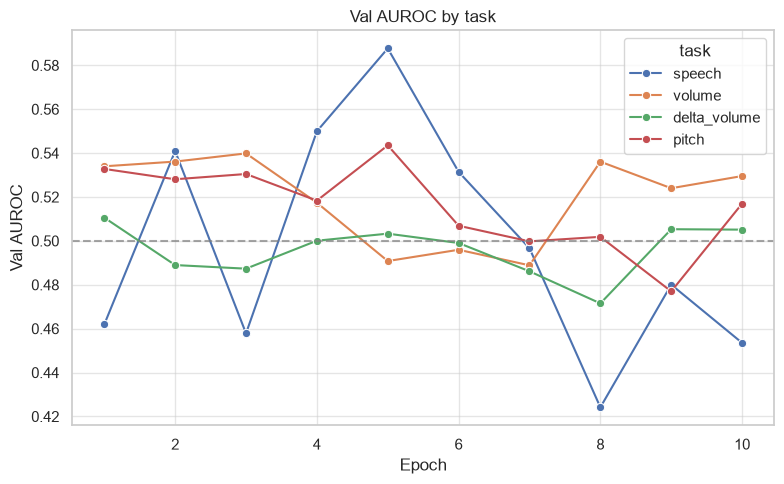

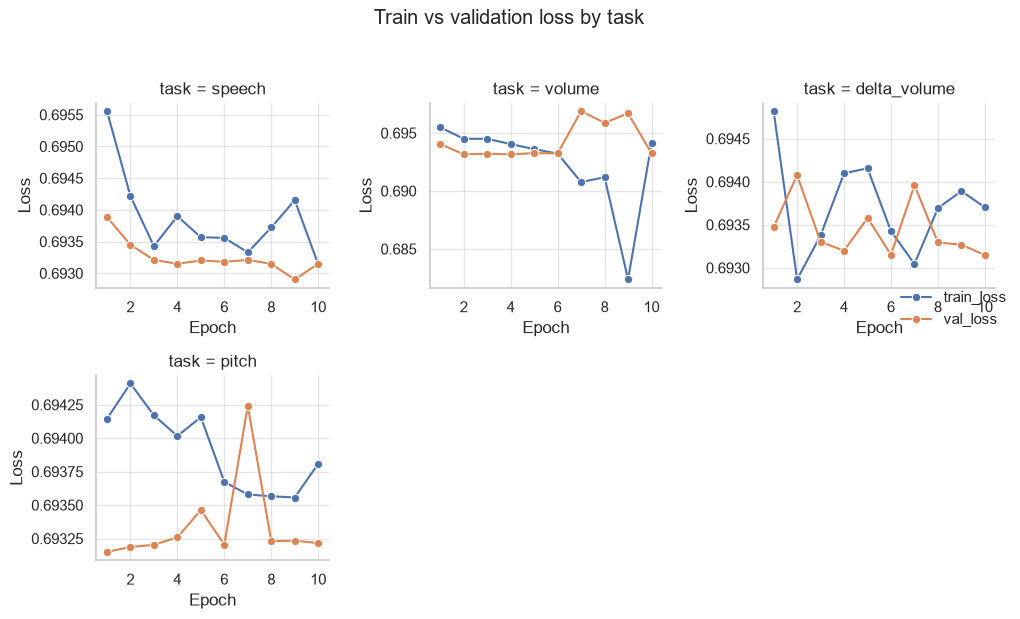

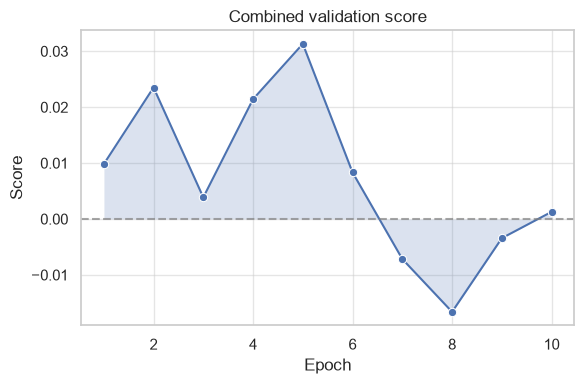

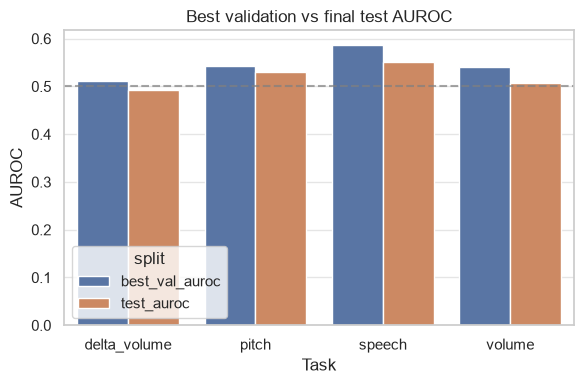

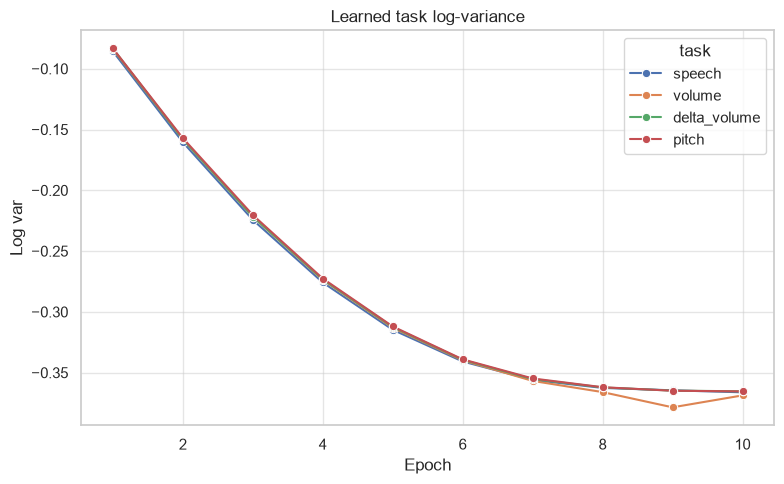

In [25]:
outdir = Path("output")
outdir.mkdir(exist_ok=True)

# Defensive copy
hist = history_df.copy()

# 0) Basic sanity / dynamic task set
if "task" not in hist.columns:
    raise ValueError("history_df must contain a 'task' column.")

if "metric" not in hist.columns or "baseline_metric" not in hist.columns:
    raise ValueError("history_df must contain 'metric' and 'baseline_metric' columns.")

# Use whatever tasks actually appear in history_df
tasks = sorted(hist["task"].unique().tolist())
print("Tasks in history_df:", tasks)

# Optional convenience alias
hist["auroc"] = hist["metric"]

# Combined score per epoch (matches combined_score() logic)
combined = (
    hist.groupby("epoch", as_index=False)
        .apply(lambda g: pd.Series({
            "combined_score": float((g["metric"] - g["baseline_metric"]).mean())
        }))
        .reset_index(drop=True)
)

sns.set(style="whitegrid")

# 1) Validation AUROC by task
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=hist,
    x="epoch",
    y="metric",
    hue="task",
    marker="o"
)
plt.axhline(0.5, ls="--", color="grey", alpha=0.7)
plt.title("Val AUROC by task")
plt.xlabel("Epoch")
plt.ylabel("Val AUROC")
plt.tight_layout()
plt.savefig(outdir / "val_auroc_by_task.png", dpi=200)
plt.show()
plt.close()

# 2) Train vs val loss by task (facets), if losses exist
loss_cols = [c for c in ["train_loss", "val_loss"] if c in hist.columns]
if loss_cols:
    loss_long = hist.melt(
        id_vars=["epoch", "task"],
        value_vars=loss_cols,
        var_name="split",
        value_name="loss"
    )

    g = sns.FacetGrid(
        loss_long,
        col="task",
        col_wrap=3,
        sharex=False,
        sharey=False,
        height=3
    )
    g.map_dataframe(
        sns.lineplot,
        x="epoch",
        y="loss",
        hue="split",
        marker="o"
    )
    g.add_legend()
    g.fig.suptitle("Train vs validation loss by task", y=1.03)
    for ax in g.axes.flatten():
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
    plt.tight_layout()
    g.savefig(outdir / "loss_by_task.png", dpi=200)
    plt.show()
    plt.close()
else:
    print("Skipping loss-by-task plot; no train_loss/val_loss columns in history_df.")

# 3) Combined score trend
plt.figure(figsize=(6, 4))
sns.lineplot(
    data=combined,
    x="epoch",
    y="combined_score",
    marker="o"
)
plt.axhline(0.0, ls="--", color="grey", alpha=0.7)
plt.fill_between(
    combined["epoch"],
    combined["combined_score"],
    0.0,
    alpha=0.2
)
plt.title("Combined validation score")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.tight_layout()
plt.savefig(outdir / "combined_score_trend.png", dpi=200)
plt.show()
plt.close()

# 4) Best val vs final test AUROC (if final_test_df present)
if "final_test_df" in globals():
    if not {"task", "test_auroc"}.issubset(final_test_df.columns):
        print("Skipping val vs test compare; final_test_df missing expected columns.")
    else:
        best_val = (
            hist.groupby("task", as_index=False)["metric"]
                .max()
                .rename(columns={"metric": "best_val_auroc"})
        )

        comp = best_val.merge(
            final_test_df[["task", "test_auroc"]],
            on="task",
            how="left"
        )

        comp_long = comp.melt(
            id_vars="task",
            value_vars=["best_val_auroc", "test_auroc"],
            var_name="split",
            value_name="auroc"
        )

        plt.figure(figsize=(6, 4))
        sns.barplot(
            data=comp_long,
            x="task",
            y="auroc",
            hue="split"
        )
        plt.axhline(0.5, ls="--", color="grey", alpha=0.7)
        plt.title("Best validation vs final test AUROC")
        plt.xlabel("Task")
        plt.ylabel("AUROC")
        plt.tight_layout()
        plt.savefig(outdir / "val_test_compare.png", dpi=200)
        plt.show()
        plt.close()
else:
    print("final_test_df not found; skipping val vs test comparison.")

# 5) Log-var trend (if column exists)
if "log_var" in hist.columns:
    plt.figure(figsize=(8, 5))
    sns.lineplot(
        data=hist,
        x="epoch",
        y="log_var",
        hue="task",
        marker="o"
    )
    plt.title("Learned task log-variance")
    plt.xlabel("Epoch")
    plt.ylabel("Log var")
    plt.tight_layout()
    plt.savefig(outdir / "logvar_trend.png", dpi=200)
    plt.show()
    plt.close()
else:
    print("Skipping log_var plot; 'log_var' column not in history_df.")